# Deep Neural Network (DNN/MLP) — Digits Classification

Build and train a **Multi-Layer Perceptron (MLP)** to classify handwritten digits (0–9) using scikit-learn's built-in `load_digits` dataset.

In [1]:
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else
                       "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 1. Load & Visualize the Digits Dataset

Dataset shape: (1797, 64)
Classes: [0 1 2 3 4 5 6 7 8 9]


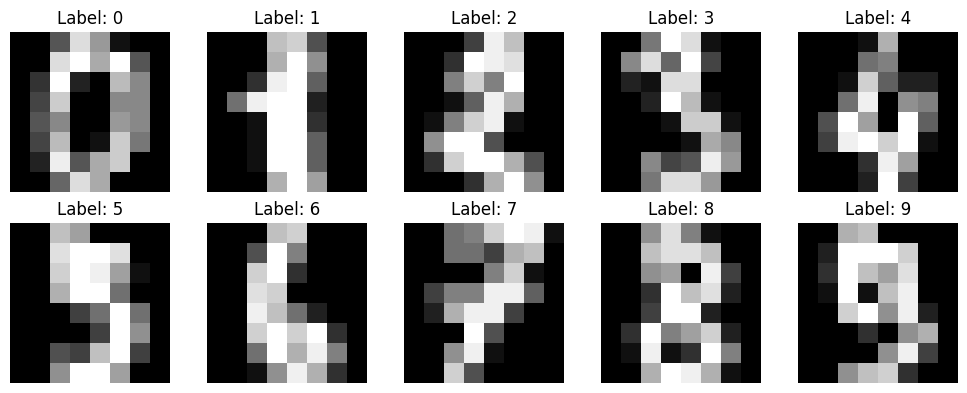

In [2]:
digits = load_digits()
print("Dataset shape:", digits.data.shape)   # (1797, 64)
print("Classes:", digits.target_names)

# Visualize first 10 images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(digits.images[i], cmap="gray")
    axes[i].set_title(f"Label: {digits.target[i]}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## 2. Preprocess Data

In [3]:
X = digits.data.astype(np.float32) / 16.0   # normalize to [0, 1]
y = digits.target.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

# Convert to tensors
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test)

Train: (1437, 64) | Test: (360, 64)


## 3. Create Dataset & DataLoader

In [4]:
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

# Check one batch
xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape, "| Batch y:", yb.shape)

Batch X: torch.Size([64, 64]) | Batch y: torch.Size([64])


## 4. Define the MLP Model

In [5]:
class MLPDigits(nn.Module):
    def __init__(self, in_dim=64, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),   # 64 → 128
            nn.ReLU(),
            nn.Linear(128, 64),       # 128 → 64
            nn.ReLU(),
            nn.Linear(64, num_classes) # 64 → 10 logits
        )

    def forward(self, x):
        return self.net(x)

model = MLPDigits(in_dim=64, num_classes=10).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

MLPDigits(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

Total parameters: 17,226


## 5. Loss Function & Optimizer

In [6]:
criterion = nn.CrossEntropyLoss()  # standard for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## 6. Training & Evaluation Functions

In [7]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct    += (logits.argmax(1) == yb).sum().item()
        total      += xb.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss   = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
        correct    += (logits.argmax(1) == yb).sum().item()
        total      += xb.size(0)
    return total_loss / total, correct / total

## 7. Train the Model

In [8]:
num_epochs = 20
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    te_loss, te_acc = evaluate(model, test_loader, criterion)

    train_losses.append(tr_loss); test_losses.append(te_loss)
    train_accs.append(tr_acc);   test_accs.append(te_acc)

    print(f"Epoch {epoch:02d} | Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | "
          f"Test Loss: {te_loss:.4f}, Acc: {te_acc:.4f}")

Epoch 01 | Train Loss: 2.2233, Acc: 0.3646 | Test Loss: 2.0904, Acc: 0.6556
Epoch 02 | Train Loss: 1.8946, Acc: 0.7495 | Test Loss: 1.5912, Acc: 0.8278
Epoch 03 | Train Loss: 1.2594, Acc: 0.8344 | Test Loss: 0.8946, Acc: 0.8583
Epoch 04 | Train Loss: 0.6856, Acc: 0.8810 | Test Loss: 0.5136, Acc: 0.9028
Epoch 05 | Train Loss: 0.4296, Acc: 0.9074 | Test Loss: 0.3726, Acc: 0.9222
Epoch 06 | Train Loss: 0.3220, Acc: 0.9255 | Test Loss: 0.2973, Acc: 0.9333
Epoch 07 | Train Loss: 0.2610, Acc: 0.9402 | Test Loss: 0.2477, Acc: 0.9306
Epoch 08 | Train Loss: 0.2217, Acc: 0.9443 | Test Loss: 0.2140, Acc: 0.9444
Epoch 09 | Train Loss: 0.1981, Acc: 0.9478 | Test Loss: 0.1941, Acc: 0.9444
Epoch 10 | Train Loss: 0.1781, Acc: 0.9492 | Test Loss: 0.1911, Acc: 0.9333
Epoch 11 | Train Loss: 0.1553, Acc: 0.9659 | Test Loss: 0.1606, Acc: 0.9500
Epoch 12 | Train Loss: 0.1421, Acc: 0.9666 | Test Loss: 0.1467, Acc: 0.9500
Epoch 13 | Train Loss: 0.1300, Acc: 0.9694 | Test Loss: 0.1509, Acc: 0.9472
Epoch 14 | T

## 8. Plot Training Curves

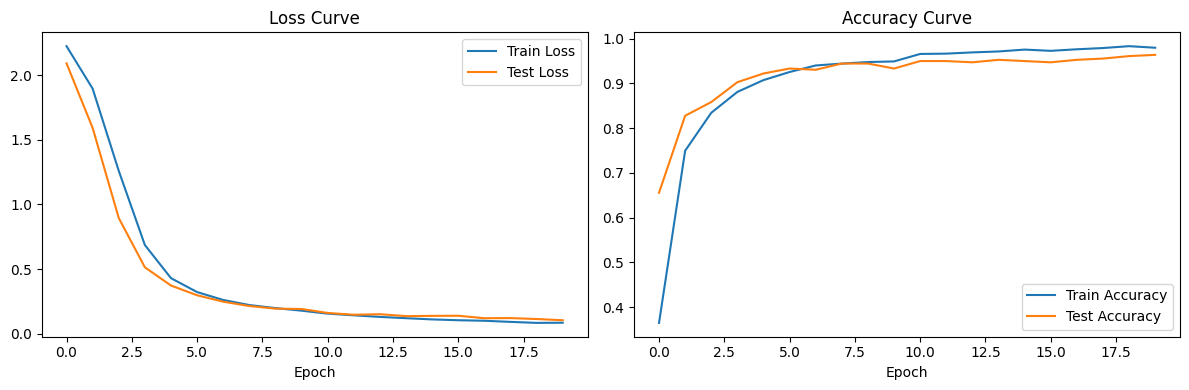

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label="Train Loss")
ax1.plot(test_losses,  label="Test Loss")
ax1.set_title("Loss Curve"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(train_accs, label="Train Accuracy")
ax2.plot(test_accs,  label="Test Accuracy")
ax2.set_title("Accuracy Curve"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout(); plt.show()

## 9. Classification Report

In [10]:
all_preds, all_true = [], []
model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_true.extend(yb.numpy())

print(classification_report(all_true, all_preds, target_names=[str(i) for i in range(10)]))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.91      0.83      0.87        36
           2       1.00      1.00      1.00        35
           3       0.97      0.97      0.97        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       0.97      0.97      0.97        36
           7       0.97      1.00      0.99        36
           8       0.91      0.91      0.91        35
           9       0.95      0.97      0.96        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



## 10. Predict on a Single Sample

In [11]:
xb, yb = next(iter(test_loader))
x_one  = xb[0].unsqueeze(0).to(device)
y_true = yb[0].item()

logits = model(x_one)
y_pred = logits.argmax(1).item()

print("True label:", y_true)
print("Predicted :", y_pred)
print("Correct!"  if y_true == y_pred else "Wrong!")

True label: 5
Predicted : 5
Correct!
